In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stan

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
df = pd.read_csv('/home/vivek/Documents/territory_geometry/processed_data/stability_ALL.csv')

# Standardise dates as years since first data point
df['date_now'] = pd.to_datetime(df['date_now'])
t0 = df['date_now'].min()
df['time_years'] = (df['date_now'] - t0).dt.days / 365.25

# Center and scale the time variable
time = df['time_years']
df['time_std'] = (time - time.mean()) / time.std()

df.head()

,lek_id,date_prev,date_now,centroid_shift,mode_shift,nn_cross_median,nn_cross_mean,nn_cross_cv,time_years,time_std
0,TalChhapar_TC,2012-10-01,2014-02-01,14.345197,25.195197,3.033985,6.864682,1.341986,0.000000,-1.453694
1,TalChhapar_TC,2014-02-01,2015-11-01,19.180344,44.531731,5.317716,9.612448,1.142450,1.746749,-0.912903
2,TalChhapar_TC,2015-11-01,2015-12-01,5.288125,33.362349,1.149035,4.630130,1.725009,1.828884,-0.887474
3,TalChhapar_TC,2015-12-01,2018-01-01,62.661803,27.941469,10.504549,24.557366,1.565752,3.915127,-0.241576
4,TalChhapar_TC,2018-01-01,2018-11-01,30.013742,65.168473,6.443491,12.524062,1.367217,4.747433,0.016105


In [3]:
# Encode lek ID as integers and assign plotting colors
df['lek_id_codes'] = df['lek_id'].astype('category').cat.codes + 1

leks = df['lek_id_codes'].unique()
colors = ['#367126', '#4545F5', '#D6604D'] 

In [4]:
crossyear_nnd = """
data {
    int<lower=1> N;               // total no. of observations
    int<lower=1> K;               // no. of leks
    array[N] int<lower=1, upper=K> group;  // lek identity
    vector[N] t;                  // centred and scaled time
    vector<lower=0>[N] y;         // cross-year NND
}

parameters {
    real mu_alpha;                // population mean intercept
    real mu_beta;                 // population mean slope
    real<lower=0> sigma_alpha;    // variation among leks (intercepts)
    real<lower=0> sigma_beta;     // variation among leks (slopes)

    vector[K] alpha_raw;          // lek intercept deviations
    vector[K] beta_raw;           // lek slope deviations

    real<lower=0> sigma;          // observation noise
}

transformed parameters {
    vector[K] alpha = mu_alpha + sigma_alpha * alpha_raw;
    vector[K] beta  = mu_beta  + sigma_beta  * beta_raw;
}

model {
    // priors
    alpha_raw ~ normal(0, 1);
    beta_raw  ~ normal(0, 1);

    mu_alpha ~ normal(0, 5);
    mu_beta  ~ normal(0, 5);
    sigma_alpha ~ exponential(1);
    sigma_beta  ~ exponential(1);
    sigma ~ exponential(1);

    y ~ normal(alpha[group] + beta[group] .* t, sigma);
}
"""

data = {
    'N': len(df),
    'K': len(df.lek_id.unique()),
    'group': df.lek_id_codes.to_numpy(),
    't': df.time_std.to_numpy(), 
    'y': df.nn_cross_median.to_numpy()
}

posterior = stan.build(crossyear_nnd, data=data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 3.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.32 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in '/tmp/httpstan_fnvqtbpd/model_2xtguk3t.stan', line 38, column 4 to column 55)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Gradient evaluation took 3.4e-05 seconds
  1000 transitions using 10 leapfrog steps per trans

In [5]:
xmin = df['time_std'].min()
xmax = df['time_std'].max()

x_pred = np.linspace(xmin,xmax, 100)
t_pred = x_pred * time.std() + time.mean() 
t_pred = pd.to_datetime(t_pred*365.25, unit='D', origin=t0)

alpha = fit['alpha']
beta  = fit['beta']

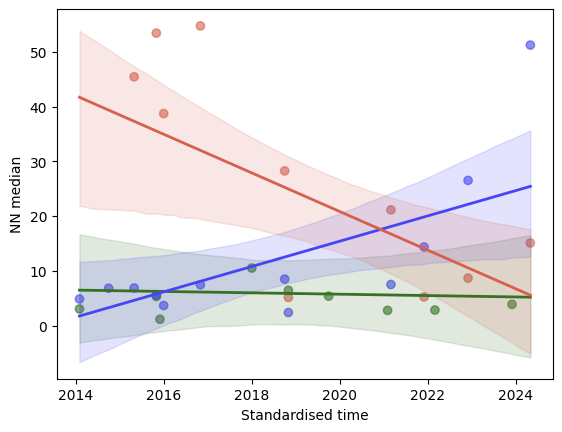

In [6]:
fig,ax = plt.subplots(1,1)

ax.scatter(df['date_now'], df['nn_cross_median'], c=df['lek_id_codes'].map(dict(zip(leks,colors))), alpha=0.6)

# posterior regression lines per lek
for lek_idx,col in zip(leks, colors):
    a = alpha[lek_idx-1,:]
    b = beta[lek_idx-1,:]
    
    y_pred = a + b * x_pred[:,None]
    
    ax.plot(t_pred, y_pred.mean(axis=1), color=col, lw=2)
    ax.fill_between(t_pred, np.quantile(y_pred, 0.025, axis=1), np.quantile(y_pred, 0.975, axis=1), color=col, alpha=0.15)

ax.set_xlabel("Standardised time")
ax.set_ylabel("NN median")
plt.show()